In [1]:
import tensorflow as tf
print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile
import os

ZIP_PATH     = '/content/drive/MyDrive/dataset_augmented.zip'  # update if in a subfolder
EXTRACT_PATH = '/content/dataset_augmented'

if not os.path.exists(EXTRACT_PATH):
    print('Unzipping dataset...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall('/content/')
    print(f'Done! Extracted to {EXTRACT_PATH}')
else:
    print('Dataset already extracted, skipping.')

folders = os.listdir(EXTRACT_PATH)
print(f'Total classes found: {len(folders)}')

Unzipping dataset...
Done! Extracted to /content/dataset_augmented
Total classes found: 59


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)
from sklearn.metrics import classification_report, confusion_matrix

# ─────────────────────────────────────────────
# CONFIG — update DATASET_PATH to your Drive path
# ─────────────────────────────────────────────
DATASET_PATH = '/content/dataset_augmented'    # <-- update this
MODEL_SAVE_PATH = '/content/drive/MyDrive/plant_disease_model.keras'

IMG_SIZE     = 224
BATCH_SIZE   = 32
EPOCHS_PHASE1 = 10   # train only top layers
EPOCHS_PHASE2 = 20   # fine-tune entire model
NUM_CLASSES  = len(os.listdir(DATASET_PATH))

print(f'Number of classes found: {NUM_CLASSES}')
print(f'Image size: {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch size: {BATCH_SIZE}')

Number of classes found: 59
Image size: 224x224
Batch size: 32


In [5]:
# EfficientNetB3 expects pixel values in [0, 255] — preprocess_input handles it
from tensorflow.keras.applications.efficientnet import preprocess_input

# Train/Validation split: 80/20
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

class_names = list(train_generator.class_indices.keys())
print(f'\nTraining samples   : {train_generator.samples}')
print(f'Validation samples : {val_generator.samples}')
print(f'Classes            : {NUM_CLASSES}')

Found 32212 images belonging to 59 classes.
Found 8026 images belonging to 59 classes.

Training samples   : 32212
Validation samples : 8026
Classes            : 59


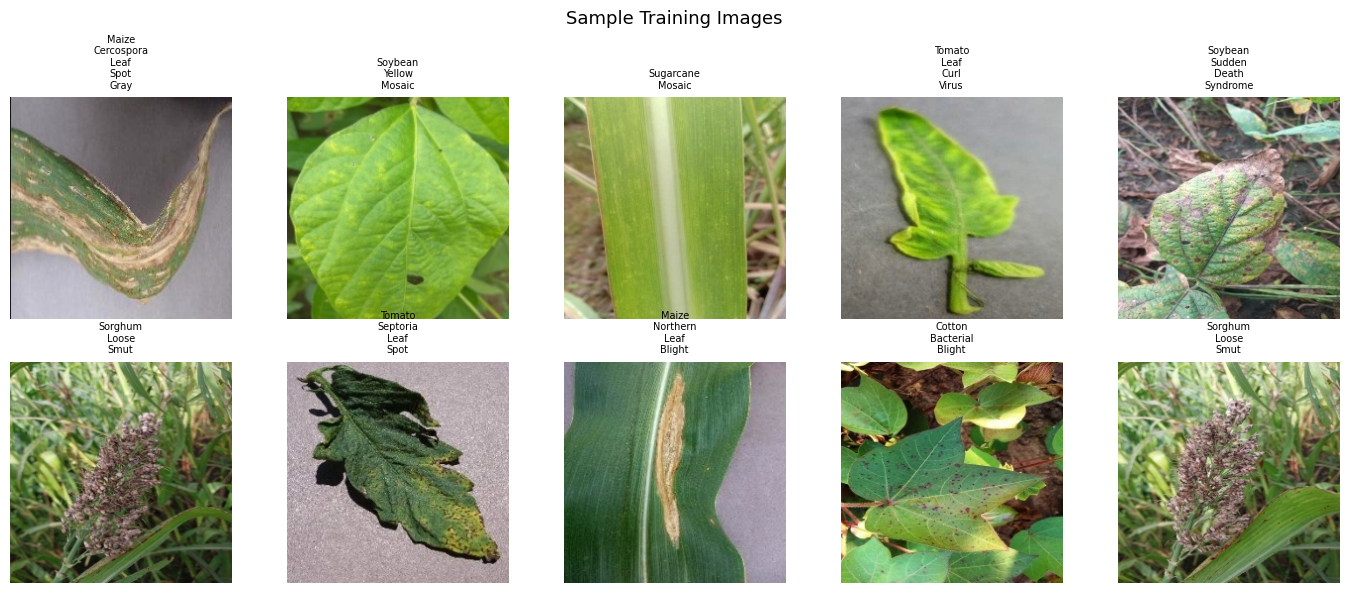

In [6]:
images, labels = next(train_generator)
class_idx = {v: k for k, v in train_generator.class_indices.items()}

plt.figure(figsize=(14, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    # Denormalize for display
    img = images[i]
    img = (img - img.min()) / (img.max() - img.min())
    plt.imshow(img)
    plt.title(class_idx[np.argmax(labels[i])].replace('_', '\n'), fontsize=7)
    plt.axis('off')
plt.suptitle('Sample Training Images', fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
def build_model(num_classes, trainable_base=False):
    # Load EfficientNetB3 pretrained on ImageNet, without top classification layer
    base_model = EfficientNetB3(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = trainable_base

    # Custom classification head
    inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x       = base_model(inputs, training=trainable_base)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dense(512, activation='relu')(x)
    x       = layers.Dropout(0.4)(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

model, base_model = build_model(NUM_CLASSES, trainable_base=False)
model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 59)             │        15,163 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,723,114 (44.72 MB)

 Trainable params: 936,507 (3.57 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase1 = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss', verbose=1),
    ModelCheckpoint('/content/best_phase1.keras', save_best_only=True, monitor='val_accuracy')
]

print('Phase 1: Training top layers only (base frozen)...')
history1 = model.fit(
    train_generator,
    epochs=EPOCHS_PHASE1,
    validation_data=val_generator,
    callbacks=callbacks_phase1
)

Phase 1: Training top layers only (base frozen)...
Epoch 1/10
1007/1007 ━━━━━━━━━━━━━━━━━━━━ 202s 153ms/step - accuracy: 0.6734 - loss: 1.1045 - val_accuracy: 0.7894 - val_loss: 0.6736 - learning_rate: 0.0010
Epoch 2/10
1007/1007 ━━━━━━━━━━━━━━━━━━━━ 93s 93ms/step - accuracy: 0.8009 - loss: 0.6158 - val_accuracy: 0.8167 - val_loss: 0.5948 - learning_rate: 0.0010
Epoch 3/10
1007/1007 ━━━━━━━━━━━━━━━━━━━━ 95s 94ms/step - accuracy: 0.8341 - loss: 0.5143 - val_accuracy: 0.8497 - val_loss: 0.4908 - learning_rate: 0.0010
Epoch 4/10
1007/1007 ━━━━━━━━━━━━━━━━━━━━ 95s 94ms/step - accuracy: 0.8495 - loss: 0.4562 - val_accuracy: 0.8500 - val_loss: 0.5383 - learning_rate: 0.0010
Epoch 5/10
1007/1007 ━━━━━━━━━━━━━━━━━━━━ 95s 94ms/step - accuracy: 0.8651 - loss: 0.4202 - val_accuracy: 0.8639 - val_loss: 0.4742 - learning_rate: 0.0010
Epoch 6/10
1007/1007 ━━━━━━━━━━━━━━━━━━━━ 95s 94ms/step - accuracy: 0.8702 - loss: 0.4029 - val_accuracy: 0.8683 - val_loss: 0.4723 - learning_rate: 0.0010
Epoch 7/10


In [9]:
# Unfreeze top 30 layers of EfficientNetB3 for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Lower learning rate for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(patience=7, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.3, patience=4, monitor='val_loss', verbose=1),
    ModelCheckpoint('/content/best_phase2.keras', save_best_only=True, monitor='val_accuracy')
]

print('Phase 2: Fine-tuning top 30 layers of EfficientNetB3...')
history2 = model.fit(
    train_generator,
    epochs=EPOCHS_PHASE2,
    validation_data=val_generator,
    callbacks=callbacks_phase2
)

Phase 2: Fine-tuning top 30 layers of EfficientNetB3...
Epoch 1/20
1007/1007 ━━━━━━━━━━━━━━━━━━━━ 199s 151ms/step - accuracy: 0.8638 - loss: 0.4470 - val_accuracy: 0.8846 - val_loss: 0.4437 - learning_rate: 1.0000e-04
Epoch 2/20
1007/1007 ━━━━━━━━━━━━━━━━━━━━ 108s 107ms/step - accuracy: 0.9170 - loss: 0.2606 - val_accuracy: 0.8943 - val_loss: 0.4419 - learning_rate: 1.0000e-04
Epoch 3/20
1007/1007 ━━━━━━━━━━━━━━━━━━━━ 107s 106ms/step - accuracy: 0.9318 - loss: 0.2129 - val_accuracy: 0.9008 - val_loss: 0.4508 - learning_rate: 1.0000e-04
Epoch 4/20
1007/1007 ━━━━━━━━━━━━━━━━━━━━ 108s 107ms/step - accuracy: 0.9445 - loss: 0.1715 - val_accuracy: 0.9103 - val_loss: 0.3893 - learning_rate: 1.0000e-04
Epoch 5/20
1007/1007 ━━━━━━━━━━━━━━━━━━━━ 107s 106ms/step - accuracy: 0.9495 - loss: 0.1589 - val_accuracy: 0.9140 - val_loss: 0.3895 - learning_rate: 1.0000e-04
Epoch 6/20
1007/1007 ━━━━━━━━━━━━━━━━━━━━ 106s 105ms/step - accuracy: 0.9557 - loss: 0.1360 - val_accuracy: 0.9123 - val_loss: 0.4160 

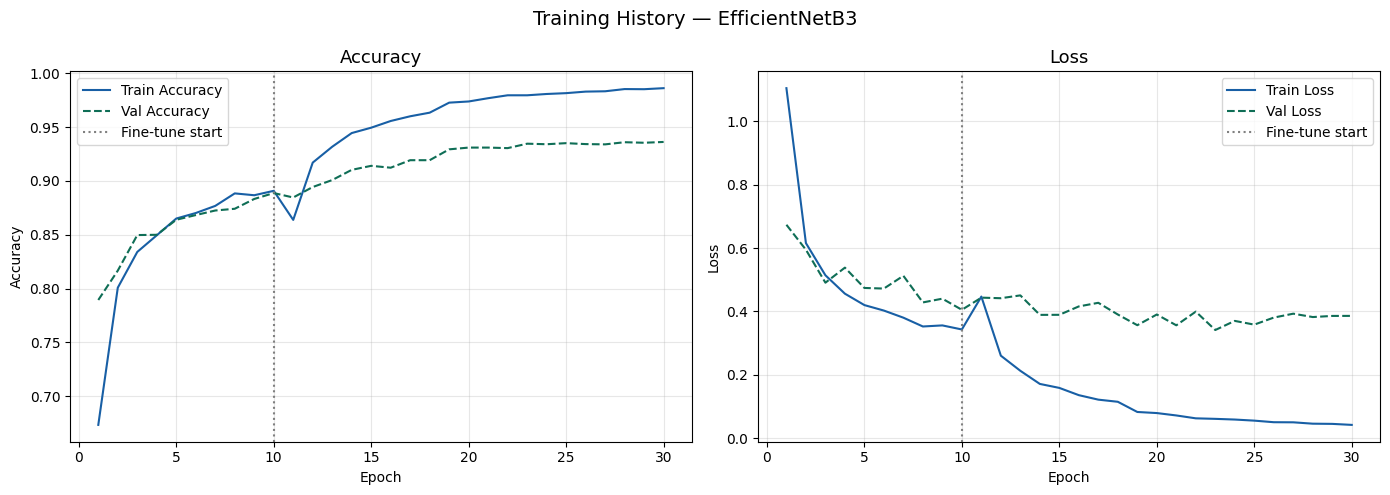

In [10]:
# Combine both phases
acc     = history1.history['accuracy']     + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss    = history1.history['loss']         + history2.history['loss']
val_loss= history1.history['val_loss']     + history2.history['val_loss']
epochs  = range(1, len(acc) + 1)
phase2_start = len(history1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(epochs, acc,     label='Train Accuracy',      color='#185FA5')
ax1.plot(epochs, val_acc, label='Val Accuracy',        color='#0F6E56', linestyle='--')
ax1.axvline(x=phase2_start, color='gray', linestyle=':', linewidth=1.5, label='Fine-tune start')
ax1.set_title('Accuracy', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(alpha=0.3)

# Loss
ax2.plot(epochs, loss,     label='Train Loss',   color='#185FA5')
ax2.plot(epochs, val_loss, label='Val Loss',     color='#0F6E56', linestyle='--')
ax2.axvline(x=phase2_start, color='gray', linestyle=':', linewidth=1.5, label='Fine-tune start')
ax2.set_title('Loss', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Training History — EfficientNetB3', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_curves.png', dpi=150)
plt.show()

In [11]:
val_loss, val_acc = model.evaluate(val_generator, verbose=1)
print(f'\nFinal Validation Accuracy : {val_acc*100:.2f}%')
print(f'Final Validation Loss     : {val_loss:.4f}')

251/251 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - accuracy: 0.9362 - loss: 0.3861

Final Validation Accuracy : 93.62%
Final Validation Loss     : 0.3861


In [12]:
val_generator.reset()
y_pred_probs = model.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

251/251 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step

Classification Report:
                                 precision    recall  f1-score   support

         Bean_Angular_Leaf_Spot      0.849     0.964     0.903       140
                   Bean_Healthy      0.948     0.907     0.927       140
                      Bean_Rust      0.785     0.807     0.796       140
        Cotton_Bacterial_Blight      0.984     0.893     0.936       140
           Cotton_Fusarium_Wilt      0.927     0.907     0.917       140
                 Cotton_Healthy      0.946     0.871     0.907       140
         Cotton_Leaf_Curl_Virus      0.969     0.879     0.921       140
            Grape_Bacterial_Rot      0.967     0.989     0.978        90
                Grape_Black_Rot      0.993     0.986     0.989       142
             Grape_Downy_Mildew      0.952     0.986     0.969       141
       Grape_Esca_Black_Measles      0.986     0.993     0.989       140
                  Grape_Healthy      1.000     1.000   

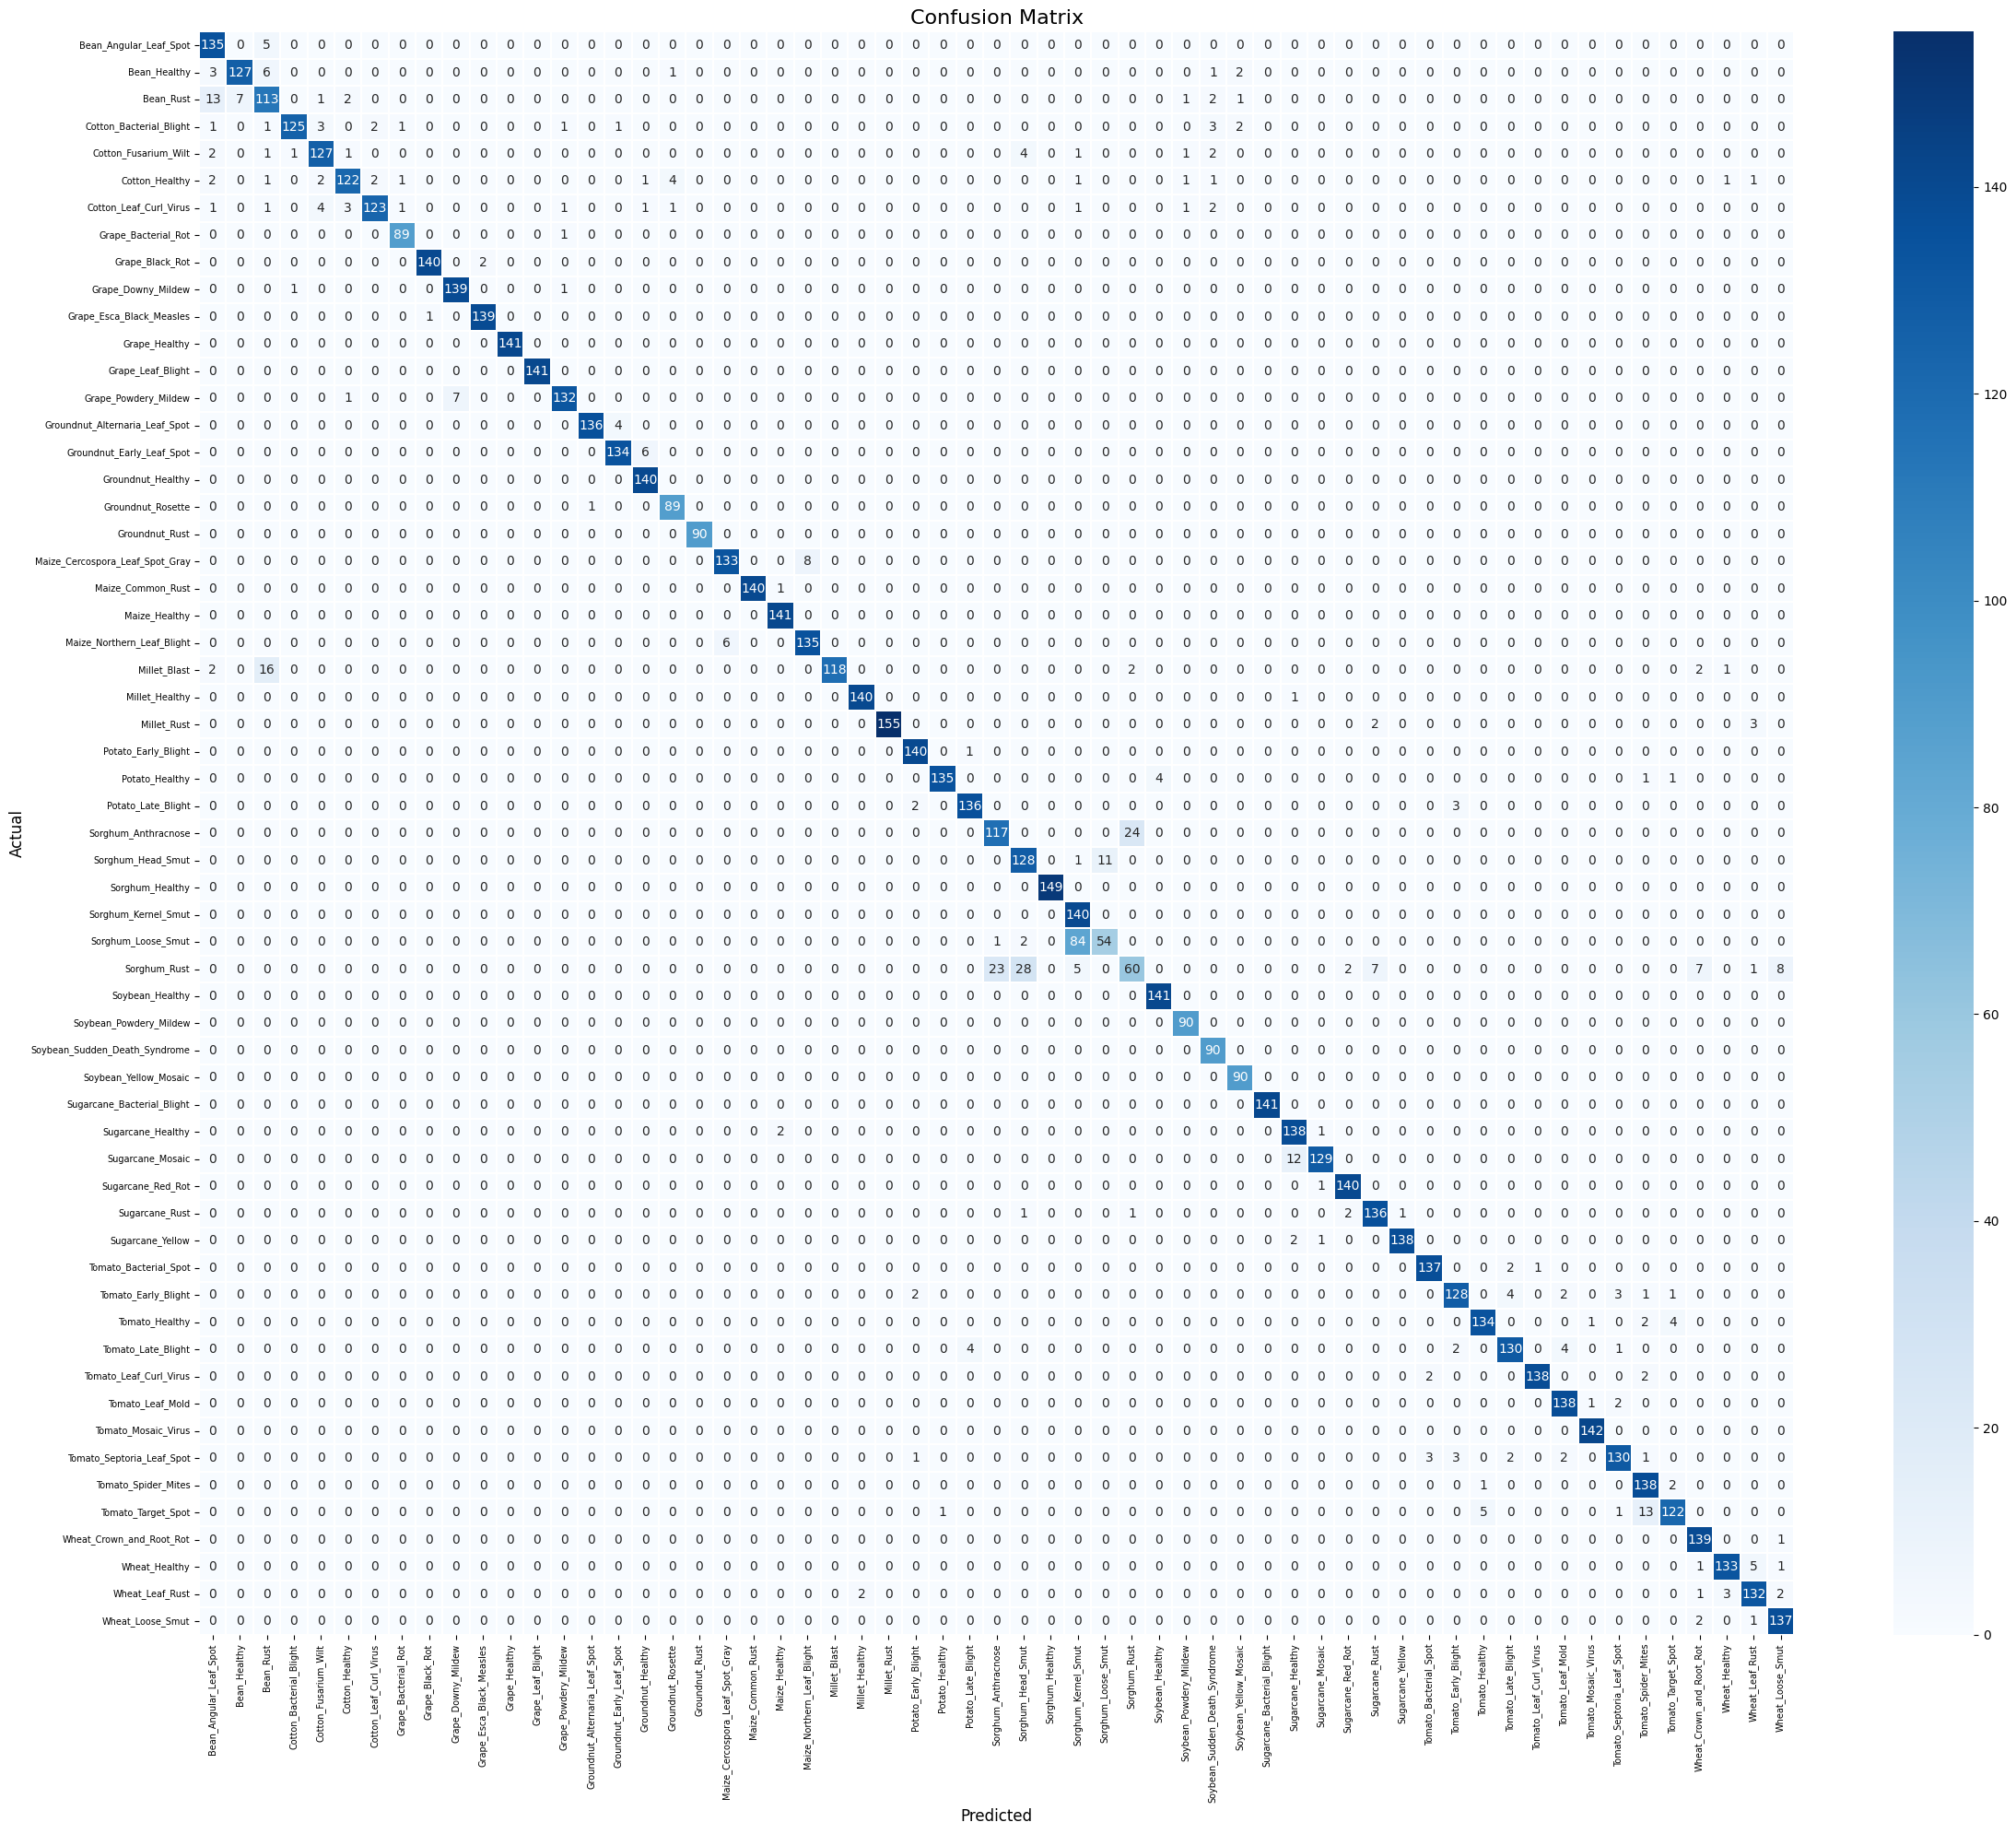

In [13]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(24, 20))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Blues',
    linewidths=0.3
)
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix.png', dpi=150)
plt.show()

In [14]:
model.save(MODEL_SAVE_PATH)
print(f'Model saved to: {MODEL_SAVE_PATH}')

# Also save class names for inference
import json
class_names_path = '/content/drive/MyDrive/class_names.json'
with open(class_names_path, 'w') as f:
    json.dump(class_names, f)
print(f'Class names saved to: {class_names_path}')

Model saved to: /content/drive/MyDrive/plant_disease_model.keras
Class names saved to: /content/drive/MyDrive/class_names.json


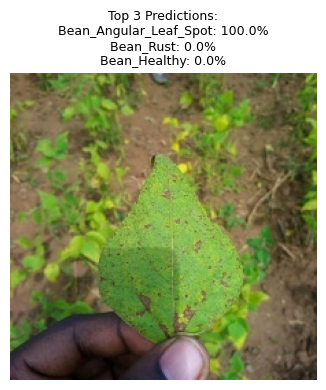


Predicted : Bean_Angular_Leaf_Spot
Confidence: 100.00%
Actual    : Bean_Angular_Leaf_Spot


In [15]:
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications.efficientnet import preprocess_input

def predict_image(img_path, model, class_names, top_k=3):
    img = keras_image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = keras_image.img_to_array(img)
    arr = preprocess_input(arr)
    arr = np.expand_dims(arr, axis=0)

    preds = model.predict(arr, verbose=0)[0]
    top_indices = preds.argsort()[-top_k:][::-1]

    plt.figure(figsize=(5, 4))
    plt.imshow(keras_image.load_img(img_path))
    plt.axis('off')
    result_text = '\n'.join([f'{class_names[i]}: {preds[i]*100:.1f}%' for i in top_indices])
    plt.title(f'Top {top_k} Predictions:\n{result_text}', fontsize=9)
    plt.tight_layout()
    plt.show()

    return class_names[top_indices[0]], preds[top_indices[0]]

# Test on a sample image from validation set
sample_path = val_generator.filepaths[0]
predicted_class, confidence = predict_image(sample_path, model, class_names)
print(f'\nPredicted : {predicted_class}')
print(f'Confidence: {confidence*100:.2f}%')
print(f'Actual    : {class_names[val_generator.classes[0]]}')